In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

#load train test split of the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target  # y: 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train shape:", X_train.shape, "test shape:", X_test.shape)
print("class balance (train):", np.bincount(y_train))

print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y.shape)
print("classes:", data.target_names) # ['malignant' 'benign']: cancerous and non-cancerous
print("y counts:", np.bincount(y))
print("feature count:", len(data.feature_names))


train shape: (455, 30) test shape: (114, 30)
class balance (train): [170 285]
X shape: (569, 30)
y shape: (569,)
classes: ['malignant' 'benign']
y counts: [212 357]
feature count: 30


In [8]:
import pandas as pd
df = pd.DataFrame(X, columns=data.feature_names)
df["label"] = y
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# build a model (scaler + logistic regression) and train
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

clf.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=2000))])

In [3]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy: {acc:.4f}")
print(f"roc-auc:  {auc:.4f}\n")

print("confusion matrix:\n", confusion_matrix(y_test, y_pred), "\n")
print("classification report:\n", classification_report(y_test, y_pred, target_names=data.target_names))


accuracy: 0.9825
roc-auc:  0.9954

confusion matrix:
 [[41  1]
 [ 1 71]] 

classification report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [4]:
feature_names = list(data.feature_names)
# 2) pick TWO features to visualize
feat1 = "mean radius"
feat2 = "mean texture"
i1, i2 = feature_names.index(feat1), feature_names.index(feat2)

X2 = X[:, [i1, i2]]

# 3) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

# 4) fit logistic regression on 2D
clf2 = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])
clf2.fit(X_train, y_train)

y_pred = clf2.predict(X_test)
y_proba = clf2.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy: {acc:.4f}")
print(f"roc-auc:  {auc:.4f}\n")

print("confusion matrix:\n", confusion_matrix(y_test, y_pred), "\n")
print("classification report:\n", classification_report(y_test, y_pred, target_names=data.target_names))


accuracy: 0.8772
roc-auc:  0.9534

confusion matrix:
 [[35  7]
 [ 7 65]] 

classification report:
               precision    recall  f1-score   support

   malignant       0.83      0.83      0.83        42
      benign       0.90      0.90      0.90        72

    accuracy                           0.88       114
   macro avg       0.87      0.87      0.87       114
weighted avg       0.88      0.88      0.88       114



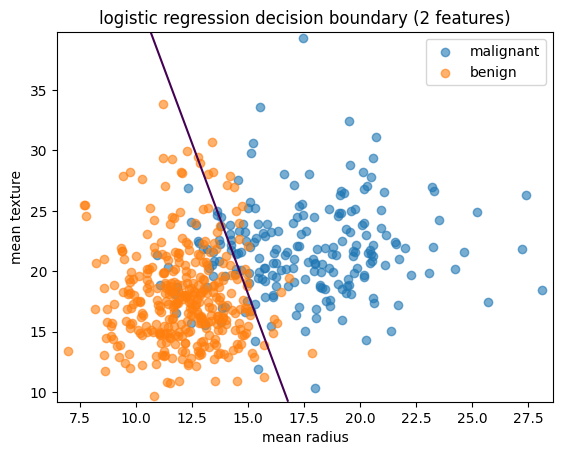

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# 5) build a mesh grid in original feature space
pad = 0.5
x_min, x_max = X2[:, 0].min() - pad, X2[:, 0].max() + pad
y_min, y_max = X2[:, 1].min() - pad, X2[:, 1].max() + pad

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
proba = clf2.predict_proba(grid)[:, 1].reshape(xx.shape)  # P(y=1)

# 6) plot: points + decision boundary (p=0.5)
plt.figure()
plt.contour(xx, yy, proba, levels=[0.5])  # decision boundary
plt.scatter(X2[y==0, 0], X2[y==0, 1], alpha=0.6, label=data.target_names[0])
plt.scatter(X2[y==1, 0], X2[y==1, 1], alpha=0.6, label=data.target_names[1])

plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title("logistic regression decision boundary (2 features)")
plt.legend()
plt.show()

In [6]:
feat_names = ["mean radius", "mean texture", "mean smoothness"]
idx = [feature_names.index(f) for f in feat_names]
X3 = X[:, idx]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X3, y, test_size=0.2, random_state=42, stratify=y
)

# 标准化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 训练 3D LR
lr3 = LogisticRegression(max_iter=2000, solver="lbfgs")
lr3.fit(X_train_s, y_train)

print("features:", feat_names)
print("coef (scaled space):", lr3.coef_)
print("intercept:", lr3.intercept_)


y_pred = lr3.predict(X_test_s)
y_proba = lr3.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy: {acc:.4f}")
print(f"roc-auc:  {auc:.4f}\n")

features: ['mean radius', 'mean texture', 'mean smoothness']
coef (scaled space): [[-3.90426055 -1.40028023 -1.83208577]]
intercept: [0.79869122]
accuracy: 0.8772
roc-auc:  0.9719



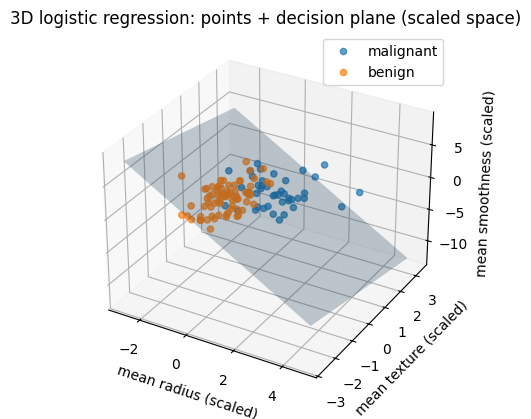

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

w = lr3.coef_.ravel()     # shape (3,)
b = lr3.intercept_[0]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# 3D scatter（用测试集更直观）
for label, name in enumerate(data.target_names):
    mask = (y_test == label)
    ax.scatter(
        X_test_s[mask, 0], X_test_s[mask, 1], X_test_s[mask, 2],
        label=name, alpha=0.7, s=20
    )

# 画平面：w1*x + w2*y + w3*z + b = 0
# 解出 z = -(w1*x + w2*y + b) / w3
x_min, x_max = X_test_s[:, 0].min() - 1, X_test_s[:, 0].max() + 1
y_min, y_max = X_test_s[:, 1].min() - 1, X_test_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 25),
                     np.linspace(y_min, y_max, 25))

# 防止 w3 太小导致数值炸
eps = 1e-9
zz = -(w[0] * xx + w[1] * yy + b) / (w[2] + eps)

ax.plot_surface(xx, yy, zz, alpha=0.25)

ax.set_xlabel(f"{feat_names[0]} (scaled)")
ax.set_ylabel(f"{feat_names[1]} (scaled)")
ax.set_zlabel(f"{feat_names[2]} (scaled)")
ax.set_title("3D logistic regression: points + decision plane (scaled space)")
ax.legend()
plt.show()
